[Previous: Module 4: Recursion, Searching and Sorting](04_Recursion_Searching_and_Sorting.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 6: Graphs](06_Graphs.ipynb)

# Module 5: Trees and Heaps

**Learning objectives.** After this module you can:

* implement a binary search tree with insert, search and traversal, and draw it;
* explain why insertion order decides the height, and why height decides the cost;
* write the four traversals (pre-order, in-order, post-order, level-order) and say what each is for;
* use a heap as a priority queue and explain the array layout behind it.

**Prerequisites.** [Module 2](02_Arrays_Linked_Lists_Stacks_Queues.ipynb) (nodes and pointers) and [Module 4](04_Recursion_Searching_and_Sorting.ipynb) (recursion).

## 1. Binary search trees

A **tree** is nodes and pointers like a linked list, except each node can point to several children. A **binary search tree** (BST) keeps one rule at every node:

$$\text{everything in the left subtree} < \text{node} < \text{everything in the right subtree}.$$

That rule turns search into a walk from the root: smaller, go left; larger, go right. Each step drops a whole subtree, so search costs the **height** of the tree.
A well-shaped tree of $n$ keys has height about $\log_2 n$; a badly shaped one can have height $n$.

search(45): True path [50, 30, 40, 45]
in-order: [20, 30, 35, 40, 45, 50, 60, 70, 80]   height: 4


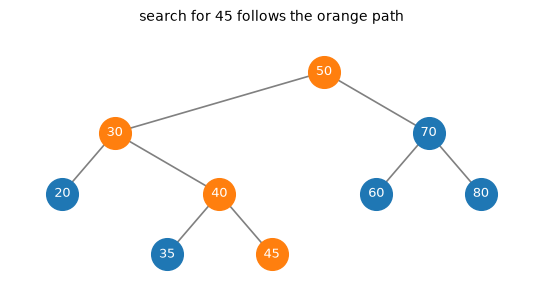

In [1]:
import random, heapq
from collections import deque
import matplotlib.pyplot as plt
from dsalab import draw_tree, draw_array

class Node:
    def __init__(self, key):
        self.key, self.left, self.right = key, None, None

class BST:
    def __init__(self):
        self.root = None

    def insert(self, key):
        if self.root is None:
            self.root = Node(key)
            return
        cur = self.root
        while True:
            if key < cur.key:
                if cur.left is None:
                    cur.left = Node(key); return
                cur = cur.left
            elif key > cur.key:
                if cur.right is None:
                    cur.right = Node(key); return
                cur = cur.right
            else:
                return                           # duplicate: ignore

    def search(self, key):
        cur, path = self.root, []
        while cur is not None:
            path.append(cur.key)
            if key == cur.key:
                return True, path
            cur = cur.left if key < cur.key else cur.right
        return False, path

    def height(self, node="root"):
        node = self.root if node == "root" else node
        return 0 if node is None else 1 + max(self.height(node.left), self.height(node.right))

    def inorder(self, node="root"):
        node = self.root if node == "root" else node
        if node is not None:
            yield from self.inorder(node.left)
            yield node.key
            yield from self.inorder(node.right)

    def draw(self, title="", highlight=()):
        return draw_tree(self.root, lambda t: (t.left, t.right), lambda t: str(t.key), title=title, highlight=highlight)

tree = BST()
for k in [50, 30, 70, 20, 40, 60, 80, 35, 45]:
    tree.insert(k)
found, path = tree.search(45)
print("search(45):", found, "path", path)
print("in-order:", list(tree.inorder()), "  height:", tree.height())

nodes_on_path = []
cur = tree.root
while cur:
    nodes_on_path.append(cur)
    cur = cur.left if 45 < cur.key else (cur.right if 45 > cur.key else None)
tree.draw(title="search for 45 follows the orange path", highlight=nodes_on_path)

> **What to notice.** In-order traversal of a BST comes out **sorted**. That is the BST rule read left to right, and it means a BST is a sorted collection
> that can still accept insertions in O(height).

## 2. Shape is everything: random vs sorted insertion

Insert the same fifteen keys in a random order and in sorted order. The random one is bushy; the sorted one is a chain, because every new key is the largest so far
and always goes right. A chain is a linked list with extra steps: search costs O(n).

Real systems use **self-balancing** trees (AVL, red-black, B-trees in databases) that rotate nodes to keep the height logarithmic whatever the insertion order.

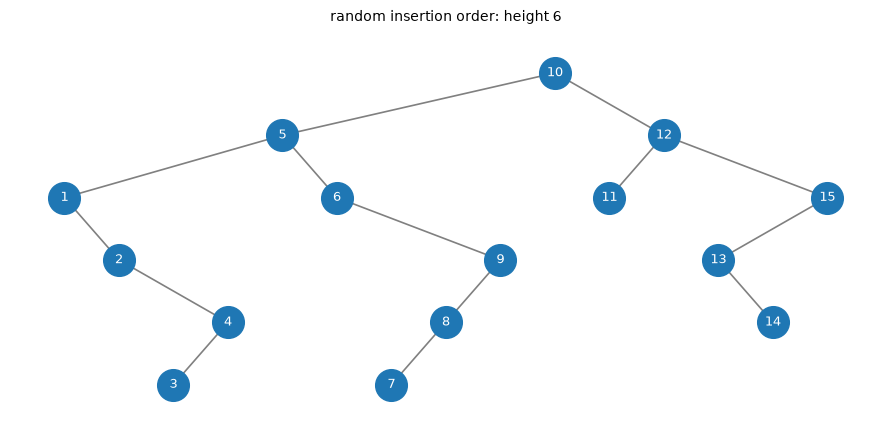

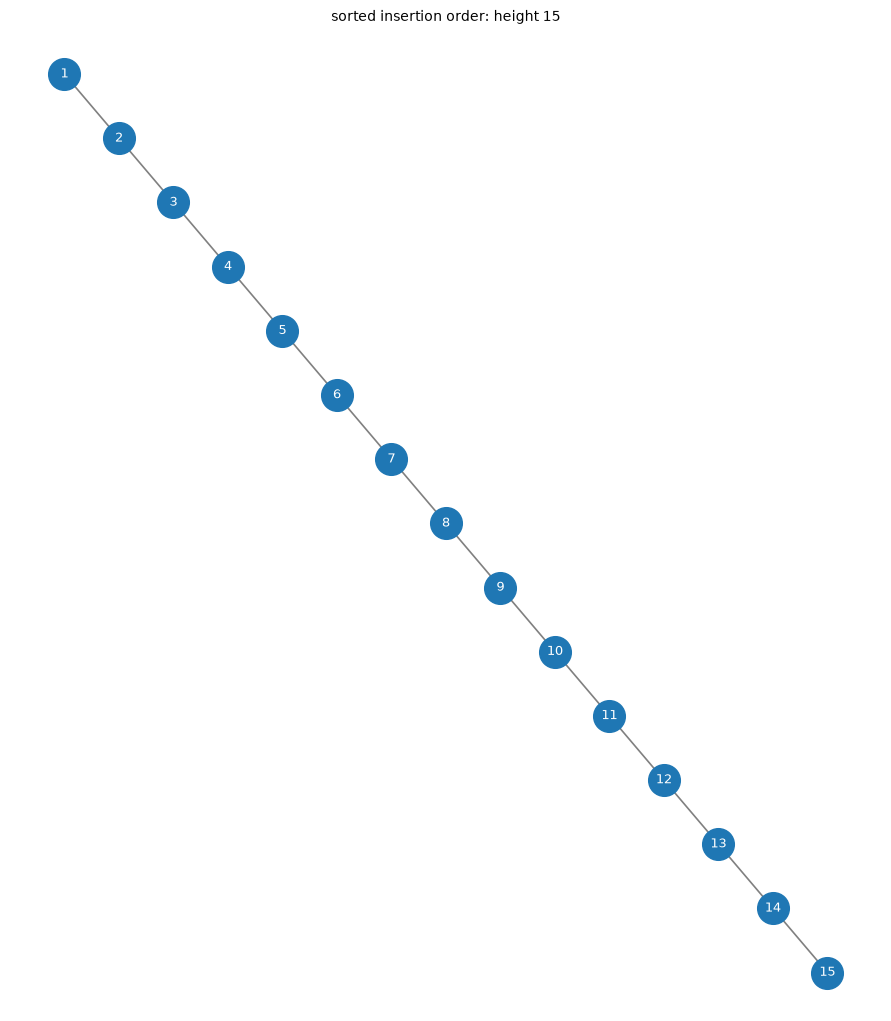

In [2]:
keys = list(range(1, 16))
random.seed(5)
shuffled = random.sample(keys, len(keys))

bushy, chain = BST(), BST()
for k in shuffled: bushy.insert(k)
for k in keys:     chain.insert(k)
display(bushy.draw(title=f"random insertion order: height {bushy.height()}"))
display(chain.draw(title=f"sorted insertion order: height {chain.height()}"))

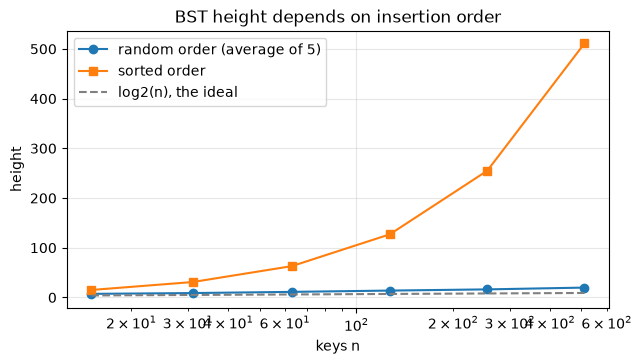

In [3]:
# Height against n: random insertion stays close to log n, sorted insertion is n.
ns = [15, 31, 63, 127, 255, 511]
random_h, sorted_h = [], []
for n in ns:
    hs = []
    for trial in range(5):
        t = BST()
        for k in random.sample(range(n), n): t.insert(k)
        hs.append(t.height())
    random_h.append(sum(hs) / len(hs))
    t = BST()
    for k in range(n): t.insert(k)
    sorted_h.append(t.height())

plt.figure(figsize=(7, 3.6))
plt.plot(ns, random_h, "o-", label="random order (average of 5)")
plt.plot(ns, sorted_h, "s-", label="sorted order")
plt.plot(ns, [n.bit_length() for n in ns], "--", color="gray", label="log2(n), the ideal")
plt.xscale("log"); plt.xlabel("keys n"); plt.ylabel("height"); plt.legend(); plt.grid(alpha=0.3)
plt.title("BST height depends on insertion order"); plt.show()

### Lab: BST Builder

Insert keys one at a time, then search and watch the path light up. Press "Insert 1..10 sorted" and see the chain; clear and press "Insert 10 random".

BST Builder (static preview). Run this cell in JupyterLab for the interactive version.


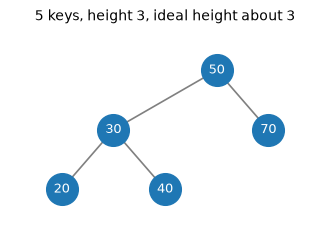

In [4]:
from dsalab import bst_builder

bst_builder([50, 30, 70, 20, 40])

## 3. Traversals

Four systematic ways to visit every node. Three are recursive and differ only in *when* the node itself is visited; the fourth uses a queue.

| Traversal | Order | Use |
|-----------|-------|-----|
| pre-order | node, left, right | copy a tree, serialise it |
| in-order | left, node, right | sorted output from a BST |
| post-order | left, right, node | delete a tree, evaluate expression trees |
| level-order | top to bottom, left to right | print by depth, shortest paths (it is BFS, Module 6) |

In [5]:
def preorder(node):
    if node: yield node.key; yield from preorder(node.left); yield from preorder(node.right)

def postorder(node):
    if node: yield from postorder(node.left); yield from postorder(node.right); yield node.key

def levelorder(root):
    queue = deque([root] if root else [])
    while queue:
        node = queue.popleft()
        yield node.key
        if node.left:  queue.append(node.left)
        if node.right: queue.append(node.right)

print("pre-order:  ", list(preorder(tree.root)))
print("in-order:   ", list(tree.inorder()))
print("post-order: ", list(postorder(tree.root)))
print("level-order:", list(levelorder(tree.root)))

pre-order:   [50, 30, 20, 40, 35, 45, 70, 60, 80]
in-order:    [20, 30, 35, 40, 45, 50, 60, 70, 80]
post-order:  [20, 35, 45, 40, 30, 60, 80, 70, 50]
level-order: [50, 30, 70, 20, 40, 60, 80, 35, 45]


## 4. Heaps: the priority queue

A **min-heap** is a binary tree with a weaker rule than a BST: each parent is smaller than its children. Only the root is guaranteed to be the minimum,
which is exactly what a **priority queue** needs: O(1) to peek at the most urgent item, O(log n) to insert or remove it.

The trick that makes heaps fast is that they live in a plain list. The children of index $i$ are at $2i+1$ and $2i+2$, so no pointers are stored at all.
Python's `heapq` module works directly on lists.

heap as a list: [3, 7, 8, 42, 25, 19, 11]    smallest is heap[0] = 3


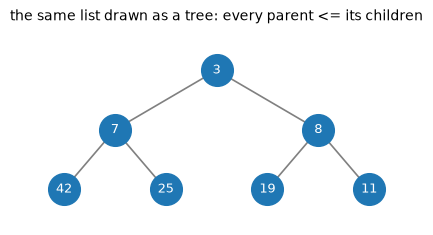

pop in order: [3, 7, 8, 11, 19, 25, 42]


In [6]:
heap = []
for x in [42, 7, 19, 3, 25, 11, 8]:
    heapq.heappush(heap, x)
print("heap as a list:", heap, "   smallest is heap[0] =", heap[0])

def heap_children(i):
    return (2 * i + 1 if 2 * i + 1 < len(heap) else None, 2 * i + 2 if 2 * i + 2 < len(heap) else None)

display(draw_tree(0, heap_children, lambda i: str(heap[i]), title="the same list drawn as a tree: every parent <= its children"))

print("pop in order:", [heapq.heappop(list_copy) for list_copy in [list(heap)] for _ in range(len(heap))])

In [7]:
# Priority queue: tasks with priorities. Tuples compare by their first element.
tasks = [(3, "write report"), (1, "fix outage"), (2, "review pull request"), (1, "call customer"), (4, "tidy desk")]
pq = []
for t in tasks:
    heapq.heappush(pq, t)
while pq:
    priority, name = heapq.heappop(pq)
    print(f"priority {priority}: {name}")

# Top-k without sorting everything: O(n log k)
import random
random.seed(6)
data = [random.randint(0, 10**6) for _ in range(100_000)]
print("\n3 largest:", heapq.nlargest(3, data), "   3 smallest:", heapq.nsmallest(3, data))

priority 1: call customer
priority 1: fix outage
priority 2: review pull request
priority 3: write report
priority 4: tidy desk

3 largest: [999945, 999935, 999926]    3 smallest: [3, 3, 4]


> **What to notice.** `heapq.nlargest(3, data)` keeps a heap of size 3 and scans once: O(n log 3). Sorting the whole list first would be O(n log n).
> Whenever you need "the best few", think heap.

## Try it yourself

**Exercise 1.** Write `is_bst(node, low, high)` that checks the BST rule for a whole tree. Build a tree that fails the check by hand.

**Exercise 2.** Find the lowest common ancestor of two keys in a BST without recursion. (Walk from the root: the first node that lies between the two keys.)

**Exercise 3.** Merge k sorted lists into one sorted list with a heap of size k. Compare with `sorted(sum(lists, []))` on timing.

**Exercise 4 (challenge).** Implement `heappush` and `heappop` yourself with sift-up and sift-down, and check against `heapq` on random data.

<details><summary>Solutions</summary>

```python
# Exercise 1
def is_bst(node, low=float("-inf"), high=float("inf")):
    if node is None: return True
    return low < node.key < high and is_bst(node.left, low, node.key) and is_bst(node.right, node.key, high)
bad = Node(10); bad.left = Node(5); bad.left.right = Node(12)      # 12 is right of 5 but left of 10: violates
print(is_bst(tree.root), is_bst(bad))

# Exercise 2
def lca(root, a, b):
    cur = root
    while cur:
        if a < cur.key and b < cur.key: cur = cur.left
        elif a > cur.key and b > cur.key: cur = cur.right
        else: return cur.key
print(lca(tree.root, 35, 45))     # 40

# Exercise 3
def merge_k(lists):
    out, heap = [], [(lst[0], i, 0) for i, lst in enumerate(lists) if lst]
    heapq.heapify(heap)
    while heap:
        value, i, j = heapq.heappop(heap)
        out.append(value)
        if j + 1 < len(lists[i]): heapq.heappush(heap, (lists[i][j + 1], i, j + 1))
    return out
print(merge_k([[1, 4, 9], [2, 3, 10], [5, 6]]))

# Exercise 4
def push(h, x):
    h.append(x); i = len(h) - 1
    while i > 0 and h[(i - 1) // 2] > h[i]:
        h[i], h[(i - 1) // 2] = h[(i - 1) // 2], h[i]; i = (i - 1) // 2
def pop(h):
    h[0], h[-1] = h[-1], h[0]; smallest = h.pop(); i = 0
    while True:
        l, r, m = 2 * i + 1, 2 * i + 2, i
        if l < len(h) and h[l] < h[m]: m = l
        if r < len(h) and h[r] < h[m]: m = r
        if m == i: return smallest
        h[i], h[m] = h[m], h[i]; i = m
h = []; [push(h, x) for x in [5, 3, 8, 1, 9, 2]]; print([pop(h) for _ in range(6)])
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [8]:
from dsalab import quiz

quiz(5)

Checkpoint quiz, Module 5 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. The binary search tree property says
    a) every node has exactly two children
    b) left subtree keys < node key < right subtree keys
    c) the tree is always balanced
    d) keys are stored in insertion order

Q2. In-order traversal of a BST visits keys in
    a) insertion order
    b) random order
    c) sorted order
    d) reverse order

Q3. Inserting the keys 1, 2, 3, ..., n in that order into a plain BST gives height
    a) log n
    b) n / 2
    c) n
    d) 1

Q4. A binary min-heap guarantees
    a) the smallest item is at the root
    b) the array is sorted
    c) O(1) search for any key
    d) no duplicates


## Key takeaways

* A BST keeps left < node < right, so search, insert and delete cost the height. In-order traversal is sorted.
* Height depends on insertion order: random gives about log n, sorted gives n. Balanced trees fix it with rotations.
* Traversals differ only in when the node is visited; level-order is BFS with a queue.
* A heap is a tree in a list with parent <= children: O(1) peek, O(log n) push and pop. It is *the* priority queue.

**Next:** nodes that can point anywhere. [Module 6](06_Graphs.ipynb).

[Previous: Module 4: Recursion, Searching and Sorting](04_Recursion_Searching_and_Sorting.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 6: Graphs](06_Graphs.ipynb)